# Churn Prediction — Baseline Model Comparison

This notebook trains and evaluates several baseline classifiers on the Cell2Cell churn dataset using a **single, consistent pipeline**:

1. One train/validation/**held-out test** split (the test set is only touched once, at the very end, per model).
2. One class-balancing strategy (SMOTE), applied identically for every model.
3. One ablation loop over feature groups, used identically for every model to pick each model's best feature group (by validation F1).
4. One shared `run_baseline_model()` function that every model calls, so results are directly comparable.

**Structure:**
- Setup → Data → Split → Preprocessing → Balancing → Feature Groups → Core CV/Test functions → Plotting functions → Shared runner
- Then **one cell per model** (Logistic Regression, Random Forest, AdaBoost, XGBoost, CatBoost, Linear SVC, MLP), each producing its own classification report + plots.
- Final cell: results table across all models.

## 1. Setup & Imports

In [ ]:
# Install required packages (run once)
!pip install imbalanced-learn xgboost catboost -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Set to True if running on a GPU-enabled runtime (Colab GPU, etc.)
USE_GPU = True

# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

RANDOM_STATE = 42
print("All imports completed successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports completed successfully!


## 2. Configuration & Data Loading

In [ ]:
dataset_path = '/content/drive/MyDrive/CSE437_Final_Project/data/'

# Main training/validation files
version1_X_file = 'X_version1_all_features.csv'
version1_y_file = 'y_version1_all_features.csv'
version2_X_file = 'X_version2_no_corr.csv'
version2_y_file = 'y_version2_no_corr.csv'

# Pre-prepared test files
test_v1_X_file = 'X_test_no_impute_version1_all_features.csv'
test_v1_y_file = 'y_test_no_impute_version1_all_features.csv'
test_v2_X_file = 'X_test_no_impute_version2_no_corr.csv'
test_v2_y_file = 'y_test_no_impute_version2_no_corr.csv'

print("--- Loading Version 1 (ALL features) ---")
X1 = pd.read_csv(f'{dataset_path}{version1_X_file}')
y1 = pd.read_csv(f'{dataset_path}{version1_y_file}').values.ravel()
X1_test = pd.read_csv(f'{dataset_path}{test_v1_X_file}')
y1_test = pd.read_csv(f'{dataset_path}{test_v1_y_file}').values.ravel()
print(f"X1 TrainVal: {X1.shape}, X1 Test: {X1_test.shape}")

print("\n--- Loading Version 2 (WITHOUT correlated features) ---")
X2 = pd.read_csv(f'{dataset_path}{version2_X_file}')
y2 = pd.read_csv(f'{dataset_path}{version2_y_file}').values.ravel()
X2_test = pd.read_csv(f'{dataset_path}{test_v2_X_file}')
y2_test = pd.read_csv(f'{dataset_path}{test_v2_y_file}').values.ravel()
print(f"X2 TrainVal: {X2.shape}, X2 Test: {X2_test.shape}")

# Toggle version here (currently using Version 1 per existing logic)
X_data, y_data = X1, y1
X_test_data, y_test_data = X1_test, y1_test

--- Loading Version 1 (ALL features) ---
X1 TrainVal: (40837, 57), X1 Test: (4320, 57)

--- Loading Version 2 (WITHOUT correlated features) ---
X2 TrainVal: (40837, 54), X2 Test: (4320, 54)


## 3. Train / Validation / Test Split

A held-out **test set** is carved out once, up front, and is never used for model selection or cross-validation — only for the single final evaluation of each model. The remaining `X_trainval` / `y_trainval` is what the CV loop (ablation study) uses.

In [ ]:
# Instead of splitting, we assign the pre-prepared files directly
X_trainval = X_data
y_trainval = y_data
X_test = X_test_data
y_test = y_test_data

print(f"Train/Val set (from file): {X_trainval.shape}, Churn rate: {y_trainval.mean()*100:.2f}%")
print(f"Held-out Test set (from file): {X_test.shape}, Churn rate: {y_test.mean()*100:.2f}%")

Train/Val set (from file): (40837, 57), Churn rate: 28.82%
Held-out Test set (from file): (4320, 57), Churn rate: 25.95%


## 4. Column Types & Preprocessing

In [ ]:
def get_column_types(X):
    """Split a dataframe's columns into numerical and categorical, dropping any ID column."""
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
    for id_col in ('CustomerID',):
        if id_col in numerical_cols:
            numerical_cols.remove(id_col)
        if id_col in categorical_cols:
            categorical_cols.remove(id_col)
    return numerical_cols, categorical_cols


def create_preprocessor(num_cols, cat_cols):
    """Standard scaler for numeric columns + one-hot encoding for categorical columns."""
    numeric_transformer = Pipeline([('scaler', StandardScaler())])
    categorical_transformer = Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ], remainder='drop')


def get_transformed_feature_names(preprocessor, num_cols, cat_cols):
    """Feature names after the ColumnTransformer (one-hot expands categorical columns)."""
    names = list(num_cols)
    try:
        encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
        names.extend(encoder.get_feature_names_out(cat_cols))
    except Exception:
        names.extend(cat_cols)
    return names

## 5. Class Balancing

**SMOTE is the balancing method used for every baseline model** (set via `BALANCING_METHOD` below), so results are comparable across models. Balancing is fit only on the training fold — never on validation or test data.

In [ ]:
BALANCING_METHOD = 'smote'          # 'none' | 'smote' | 'smote_tomek' | 'undersample'
SAMPLING_STRATEGY = 1.0             # minority:majority ratio target


def apply_balancing(X, y, method=BALANCING_METHOD, sampling_strategy=SAMPLING_STRATEGY,
                     random_state=RANDOM_STATE):
    """Resample the training data to reduce class imbalance."""
    if method == 'none':
        return X, y
    elif method == 'undersample':
        sampler = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=random_state)
    elif method == 'smote':
        sampler = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state, k_neighbors=5)
    elif method == 'smote_tomek':
        sampler = SMOTETomek(sampling_strategy=sampling_strategy, random_state=random_state)
    else:
        raise ValueError(f"Unknown balancing method: {method}")

    X_res, y_res = sampler.fit_resample(X, y)
    return X_res, y_res

## 6. Feature Groups (Ablation Study Setup)

Every baseline model is run once per feature group below, using the **same CV + balancing setup**, so each model's best feature group is chosen the same way (highest mean validation F1).

In [ ]:
def get_feature_groups():
    """Feature groups for the ablation study (Version 2 columns)."""
    all_features = [
        'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
        'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
        'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls',
        'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
        'ThreewayCalls', 'OutboundCalls', 'InboundCalls',
        'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
        'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
        'ActiveSubs', 'Handsets', 'CurrentEquipmentDays',
        'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted',
        'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating',
        'ChildrenInHH', 'HandsetRefurbished',
        'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership',
        'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings',
        'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser',
        'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice',
        'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode',
        'Occupation', 'MaritalStatus', 'ServiceArea', 'ReceivedCalls',
        'UniqueSubs', 'HandsetModels'
    ]

    return {
        'All Features': all_features,
        'Usage Features': [
            'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
            'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
            'PercChangeMinutes', 'PercChangeRevenues'
        ],
        'Call Quality Features': [
            'DroppedCalls', 'BlockedCalls', 'UnansweredCalls',
            'CustomerCareCalls', 'DroppedBlockedCalls'
        ],
        'Demographics': [
            'AgeHH1', 'AgeHH2', 'IncomeGroup', 'ChildrenInHH',
            'MaritalStatus', 'Occupation', 'CreditRating', 'PrizmCode'
        ],
        'Equipment Features': [
            'Handsets', 'CurrentEquipmentDays', 'HandsetRefurbished',
            'HandsetWebCapable', 'HandsetPrice'
        ],
        'Service Features': [
            'MonthsInService', 'ActiveSubs', 'RetentionCalls',
            'RetentionOffersAccepted', 'MadeCallToRetentionTeam'
        ],
        'Behavior Features': [
            'ThreewayCalls', 'CallForwardingCalls', 'CallWaitingCalls',
            'ReferralsMadeBySubscriber', 'AdjustmentsToCreditRating'
        ],
        'Selected Features': [
            'MonthlyRevenue', 'MonthlyMinutes', 'OverageMinutes',
            'DroppedCalls', 'CustomerCareCalls', 'MonthsInService',
            'Handsets', 'CurrentEquipmentDays', 'AgeHH1', 'IncomeGroup',
            'RetentionCalls', 'HasCreditCard', 'PrizmCode', 'ServiceArea',
            'ReceivedCalls', 'UniqueSubs', 'HandsetModels'
        ]
    }


def filter_features(X, feature_list):
    """Keep only the specified, existing features from X."""
    available = [f for f in feature_list if f in X.columns]
    missing = [f for f in feature_list if f not in X.columns]
    if missing:
        print(f"Warning: features not found and skipped: {missing}")
    return X[available].copy()


FEATURE_GROUPS = get_feature_groups()
CV_FOLDS = 5

## 7. Core Training / Evaluation Functions

Two functions, used identically by every model:
- `train_and_evaluate_cv` — stratified k-fold CV on the train/val portion only (model selection).
- `evaluate_on_test` — fits once on the full balanced train/val portion, evaluates once on the held-out test set.

In [ ]:
def _get_scores(model, X):
    """Return positive-class scores for ROC-AUC, using predict_proba if available,
    otherwise falling back to decision_function (e.g. LinearSVC)."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def _get_feature_importance(model):
    if hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    if hasattr(model, 'coef_'):
        return np.abs(model.coef_[0])
    return None


def train_and_evaluate_cv(X, y, model, preprocessor, balancing_method=BALANCING_METHOD,
                           cv_folds=CV_FOLDS, random_state=RANDOM_STATE):
    """Stratified k-fold CV. Preprocessing and balancing are (re)fit on each training fold only."""
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    fold_metrics = {'train_acc': [], 'val_acc': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        prep = clone(preprocessor)
        X_train_proc = prep.fit_transform(X_train)
        X_val_proc = prep.transform(X_val)

        X_train_bal, y_train_bal = apply_balancing(X_train_proc, y_train, method=balancing_method)

        model_clone = clone(model)
        model_clone.fit(X_train_bal, y_train_bal)

        y_pred = model_clone.predict(X_val_proc)
        y_scores = _get_scores(model_clone, X_val_proc)
        train_acc = accuracy_score(y_train_bal, model_clone.predict(X_train_bal))

        fold_metrics['train_acc'].append(train_acc)
        fold_metrics['val_acc'].append(accuracy_score(y_val, y_pred))
        fold_metrics['precision'].append(precision_score(y_val, y_pred))
        fold_metrics['recall'].append(recall_score(y_val, y_pred))
        fold_metrics['f1'].append(f1_score(y_val, y_pred))
        fold_metrics['roc_auc'].append(roc_auc_score(y_val, y_scores))

    avg_metrics = {k: float(np.mean(v)) for k, v in fold_metrics.items()}
    std_metrics = {k: float(np.std(v)) for k, v in fold_metrics.items()}
    return avg_metrics, std_metrics, fold_metrics


def evaluate_on_test(X_trainval, y_trainval, X_test, y_test, model, preprocessor,
                      balancing_method=BALANCING_METHOD):
    """Fit once on the full (balanced) train/val set, evaluate once on the held-out test set."""
    prep = clone(preprocessor)
    X_trainval_proc = prep.fit_transform(X_trainval)
    X_test_proc = prep.transform(X_test)

    X_bal, y_bal = apply_balancing(X_trainval_proc, y_trainval, method=balancing_method)

    final_model = clone(model)
    final_model.fit(X_bal, y_bal)

    y_pred = final_model.predict(X_test_proc)
    y_scores = _get_scores(final_model, X_test_proc)
    feature_importance = _get_feature_importance(final_model)

    return {
        'model': final_model,
        'preprocessor': prep,   # fitted — use this (not the CV-time unfitted one) for feature names
        'y_true': y_test,
        'y_pred': y_pred,
        'y_scores': y_scores,
        'feature_importance': feature_importance,
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_scores),
        }
    }

## 8. Plotting Functions

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name, feature_set_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix (Test Set) — {model_name}\n{feature_set_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


def plot_fold_performance(fold_metrics, model_name, feature_set_name):
    folds = range(1, len(fold_metrics['val_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(folds, fold_metrics['train_acc'], 'bo-', label='Train Accuracy')
    axes[0].plot(folds, fold_metrics['val_acc'], 'ro-', label='Validation Accuracy')
    axes[0].axhline(y=np.mean(fold_metrics['val_acc']), color='r', linestyle='--',
                     label=f"Mean Val Acc: {np.mean(fold_metrics['val_acc']):.4f}")
    axes[0].set_xlabel('Fold'); axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'CV Accuracy — {model_name}')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(folds, fold_metrics['precision'], label='Precision')
    axes[1].plot(folds, fold_metrics['recall'], label='Recall')
    axes[1].plot(folds, fold_metrics['f1'], label='F1-Score')
    axes[1].plot(folds, fold_metrics['roc_auc'], label='ROC-AUC')
    axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Score')
    axes[1].set_title(f'CV Metrics — {model_name}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Feature Set: {feature_set_name}')
    plt.tight_layout()
    plt.show()


def plot_feature_importance(feature_importance, feature_names, model_name, top_k=20):
    if feature_importance is None:
        print(f"No feature importance available for {model_name}")
        return
    top_k = min(top_k, len(feature_importance), len(feature_names))
    indices = np.argsort(feature_importance)[-top_k:]
    top_features = [feature_names[i] for i in indices]
    top_scores = feature_importance[indices]

    plt.figure(figsize=(9, max(4, top_k * 0.35)))
    plt.barh(top_features, top_scores, color='steelblue')
    plt.xlabel('Importance Score')
    plt.title(f'Top {top_k} Features — {model_name}')
    plt.tight_layout()
    plt.show()


def print_classification_report(y_true, y_pred, model_name):
    print(f"\nClassification Report (Held-out Test Set) — {model_name}")
    print("-" * 55)
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))

## 9. Shared Baseline Model Runner

Every model cell below calls this **one** function. It:
1. Runs CV (train/val, balanced with SMOTE) on each feature group.
2. Picks the feature group with the best mean validation F1.
3. Refits on the full train/val set and evaluates **once** on the held-out test set.
4. Prints the classification report and shows the plots for that best combination.

In [ ]:
ALL_MODEL_RESULTS = {}   # populated by each model cell below


def run_baseline_model(model, model_name, feature_groups=FEATURE_GROUPS,
                        X_trainval=X_trainval, y_trainval=y_trainval,
                        X_test=X_test, y_test=y_test,
                        balancing_method=BALANCING_METHOD, cv_folds=CV_FOLDS):
    print("=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)

    ablation_rows = []
    cv_cache = {}

    for group_name, feature_list in feature_groups.items():
        X_group = filter_features(X_trainval, feature_list)
        num_cols, cat_cols = get_column_types(X_group)
        preprocessor = create_preprocessor(num_cols, cat_cols)

        avg_metrics, std_metrics, fold_metrics = train_and_evaluate_cv(
            X_group, y_trainval, model, preprocessor,
            balancing_method=balancing_method, cv_folds=cv_folds
        )
        cv_cache[group_name] = (avg_metrics, fold_metrics, preprocessor, num_cols, cat_cols)

        ablation_rows.append({
            'Feature Group': group_name,
            'Val Accuracy': avg_metrics['val_acc'],
            'Precision': avg_metrics['precision'],
            'Recall': avg_metrics['recall'],
            'F1': avg_metrics['f1'],
            'ROC-AUC': avg_metrics['roc_auc'],
        })

    ablation_df = pd.DataFrame(ablation_rows).sort_values('F1', ascending=False).reset_index(drop=True)
    print("\nAblation study (CV on train/val set, by feature group):")
    print(ablation_df.to_string(index=False))

    best_group = ablation_df.iloc[0]['Feature Group']
    print(f"\nBest feature group by CV F1: '{best_group}'")

    best_avg_metrics, best_fold_metrics, best_preprocessor, num_cols, cat_cols = cv_cache[best_group]

    # Final, single evaluation on the untouched held-out test set
    X_trainval_best = filter_features(X_trainval, feature_groups[best_group])
    X_test_best = filter_features(X_test, feature_groups[best_group])

    test_result = evaluate_on_test(
        X_trainval_best, y_trainval, X_test_best, y_test,
        model, best_preprocessor, balancing_method=balancing_method
    )

    print(f"\nFinal test-set performance ({model_name}, '{best_group}'):")
    for k, v in test_result['test_metrics'].items():
        print(f"  {k}: {v:.4f}")

    print_classification_report(test_result['y_true'], test_result['y_pred'], model_name)
    plot_confusion_matrix(test_result['y_true'], test_result['y_pred'], model_name, best_group)
    plot_fold_performance(best_fold_metrics, model_name, best_group)

    # Use the FITTED preprocessor from the final test-set fit, not the unfitted CV-time one,
    # so one-hot-expanded feature names line up with the feature_importance array length.
    feature_names = get_transformed_feature_names(test_result['preprocessor'], num_cols, cat_cols)
    plot_feature_importance(test_result['feature_importance'], feature_names, model_name)

    ALL_MODEL_RESULTS[model_name] = {
        'best_feature_group': best_group,
        'cv_metrics': best_avg_metrics,
        'test_metrics': test_result['test_metrics'],
        'ablation_table': ablation_df,
    }
    return ALL_MODEL_RESULTS[model_name]

## 10. Baseline Model: Logistic Regression

MODEL: Logistic Regression

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
         All Features      0.578911   0.355330 0.566232 0.436601 0.604777
       Usage Features      0.522198   0.329392 0.635144 0.433800 0.578063
    Selected Features      0.569312   0.346266 0.556801 0.426970 0.590753
Call Quality Features      0.431986   0.300803 0.733113 0.426567 0.533994
    Behavior Features      0.424126   0.296902 0.729118 0.421924 0.524872
         Demographics      0.501628   0.311926 0.604809 0.411540 0.546105
   Equipment Features      0.579205   0.332846 0.457898 0.385459 0.582781
     Service Features      0.594632   0.302103 0.310814 0.306376 0.538291

Best feature group by CV F1: 'All Features'

Final test-set performance (Logistic Regression, 'All Features'):
  accuracy: 0.6271
  precision: 0.3457
  recall: 0.4897
  f1: 0.4053
  roc_auc: 0.6142

Classification Report (Held-out Test Set) — Logist

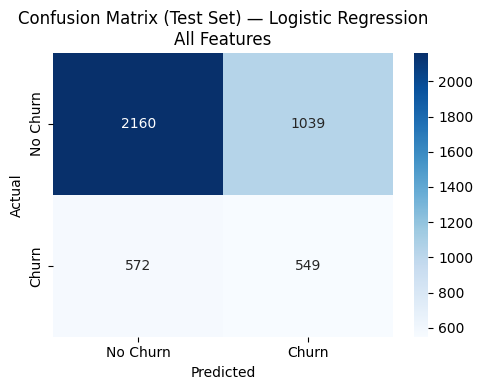

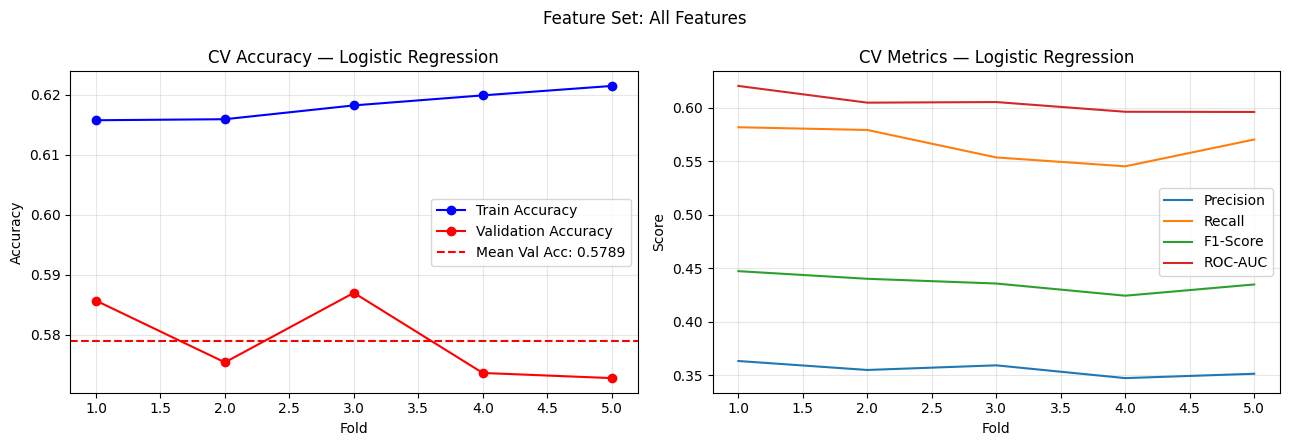

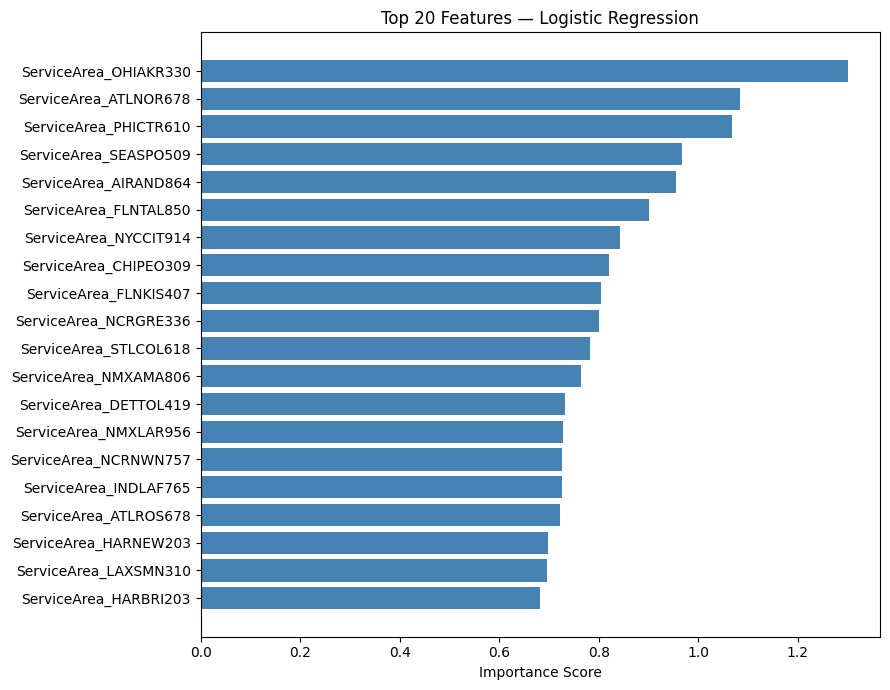

{'best_feature_group': 'All Features',
 'cv_metrics': {'train_acc': 0.6182442474761579,
  'val_acc': 0.5789112007701138,
  'precision': 0.3553298127469292,
  'recall': 0.566232265178927,
  'f1': 0.4366010894876668,
  'roc_auc': 0.6047774313528392},
 'test_metrics': {'accuracy': 0.6270833333333333,
  'precision': 0.34571788413098237,
  'recall': 0.4897413024085638,
  'f1': 0.4053156146179402,
  'roc_auc': np.float64(0.6142045392753478)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0           All Features      0.578911   0.355330  0.566232  0.436601   
 1         Usage Features      0.522198   0.329392  0.635144  0.433800   
 2      Selected Features      0.569312   0.346266  0.556801  0.426970   
 3  Call Quality Features      0.431986   0.300803  0.733113  0.426567   
 4      Behavior Features      0.424126   0.296902  0.729118  0.421924   
 5           Demographics      0.501628   0.311926  0.604809  0.411540   
 6     Equipment Featur

In [ ]:
model = LogisticRegression(
    max_iter=100,
    C=1.0,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

run_baseline_model(model, "Logistic Regression")

## 11. Baseline Model: Random Forest

MODEL: Random Forest

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
     Service Features      0.557926   0.340071 0.567084 0.424948 0.593978
    Behavior Features      0.454661   0.293715 0.635650 0.400373 0.511437
   Equipment Features      0.584421   0.340290 0.470812 0.395030 0.556345
         Demographics      0.589588   0.307525 0.339199 0.322448 0.515015
Call Quality Features      0.602125   0.311665 0.315064 0.313345 0.519153
       Usage Features      0.663810   0.374042 0.247175 0.297643 0.571836
    Selected Features      0.695864   0.438444 0.196533 0.271375 0.633317
         All Features      0.706541   0.463844 0.116832 0.186560 0.635617

Best feature group by CV F1: 'Service Features'

Final test-set performance (Random Forest, 'Service Features'):
  accuracy: 0.5352
  precision: 0.3005
  recall: 0.5959
  f1: 0.3995
  roc_auc: 0.5790

Classification Report (Held-out Test Set) — Random For

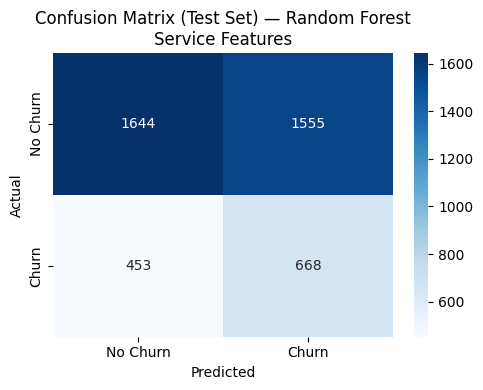

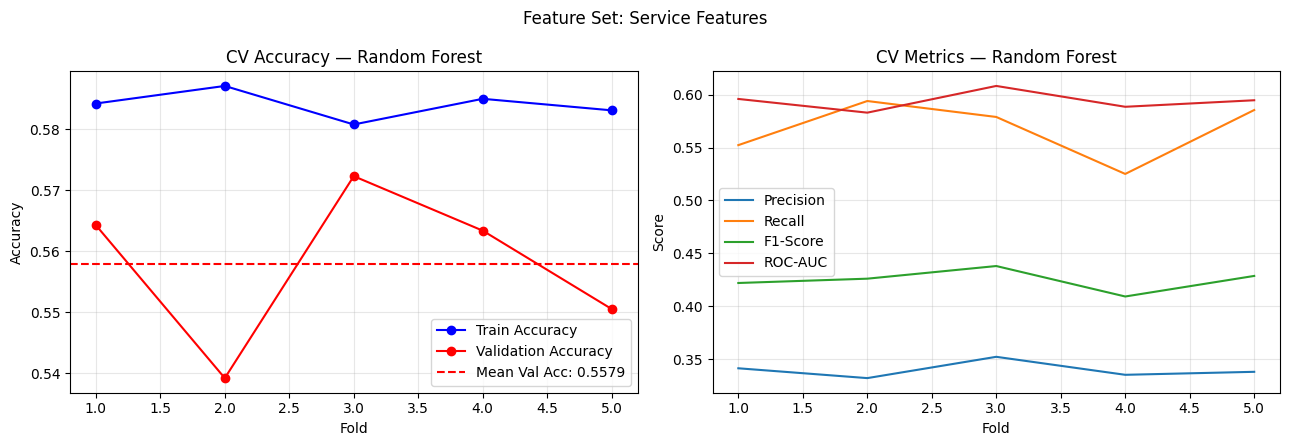

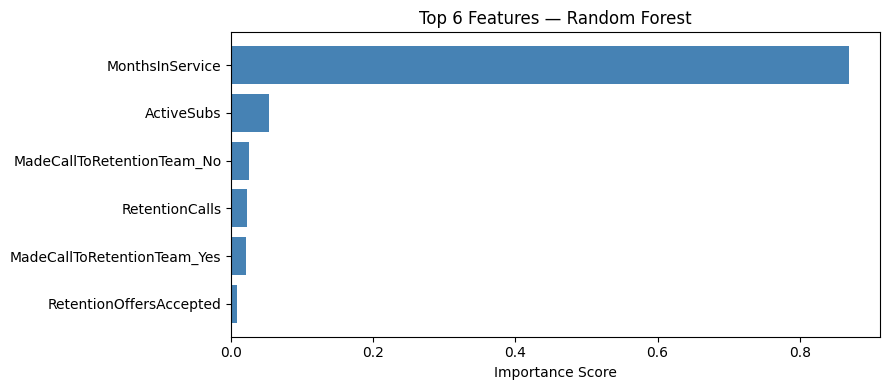

{'best_feature_group': 'Service Features',
 'cv_metrics': {'train_acc': 0.5840400095219467,
  'val_acc': 0.5579257143994723,
  'precision': 0.3400705887493546,
  'recall': 0.5670840132140281,
  'f1': 0.4249484871963757,
  'roc_auc': 0.5939780964701331},
 'test_metrics': {'accuracy': 0.5351851851851852,
  'precision': 0.3004948268106163,
  'recall': 0.5958965209634255,
  'f1': 0.39952153110047844,
  'roc_auc': np.float64(0.5790262846970187)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0       Service Features      0.557926   0.340071  0.567084  0.424948   
 1      Behavior Features      0.454661   0.293715  0.635650  0.400373   
 2     Equipment Features      0.584421   0.340290  0.470812  0.395030   
 3           Demographics      0.589588   0.307525  0.339199  0.322448   
 4  Call Quality Features      0.602125   0.311665  0.315064  0.313345   
 5         Usage Features      0.663810   0.374042  0.247175  0.297643   
 6      Selected F

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

run_baseline_model(model, "Random Forest")

## 12. Baseline Model: AdaBoost

MODEL: AdaBoost

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
    Selected Features      0.483263   0.333759 0.795053 0.470046 0.602137
     Service Features      0.426549   0.319823 0.878494 0.468928 0.597355
         All Features      0.515807   0.340857 0.728270 0.464330 0.601372
   Equipment Features      0.543478   0.349902 0.680857 0.462246 0.600538
         Demographics      0.401817   0.302931 0.826748 0.443394 0.532845
Call Quality Features      0.506722   0.308567 0.573111 0.400885 0.537061
    Behavior Features      0.474276   0.298776 0.608377 0.398092 0.521368
       Usage Features      0.603129   0.334006 0.377693 0.352979 0.549407

Best feature group by CV F1: 'Selected Features'

Final test-set performance (AdaBoost, 'Selected Features'):
  accuracy: 0.4500
  precision: 0.2828
  recall: 0.7288
  f1: 0.4075
  roc_auc: 0.5724

Classification Report (Held-out Test Set) — AdaBoost
---------

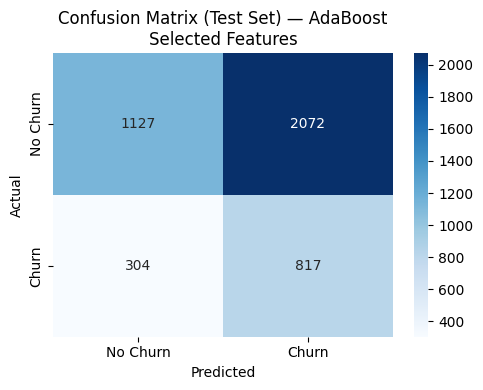

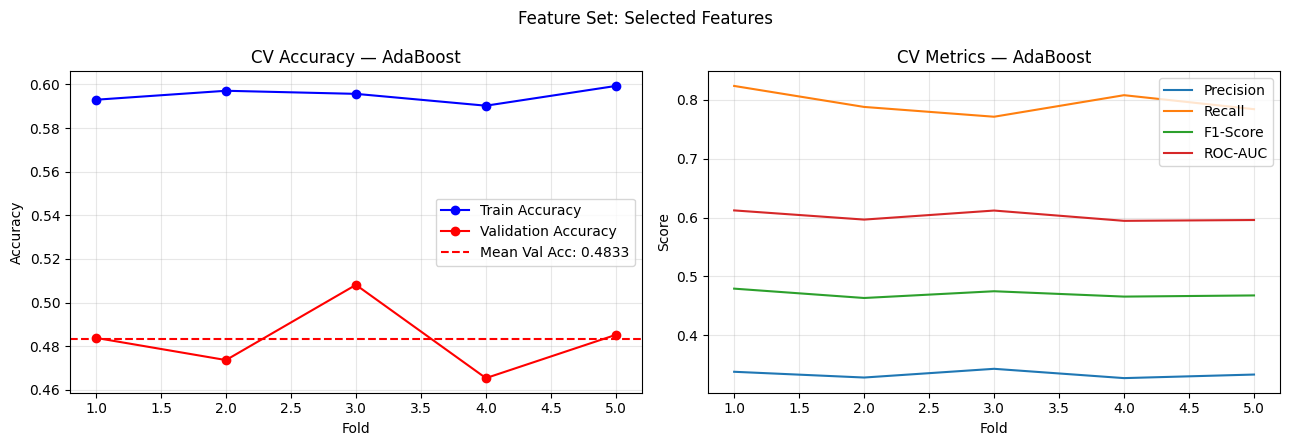

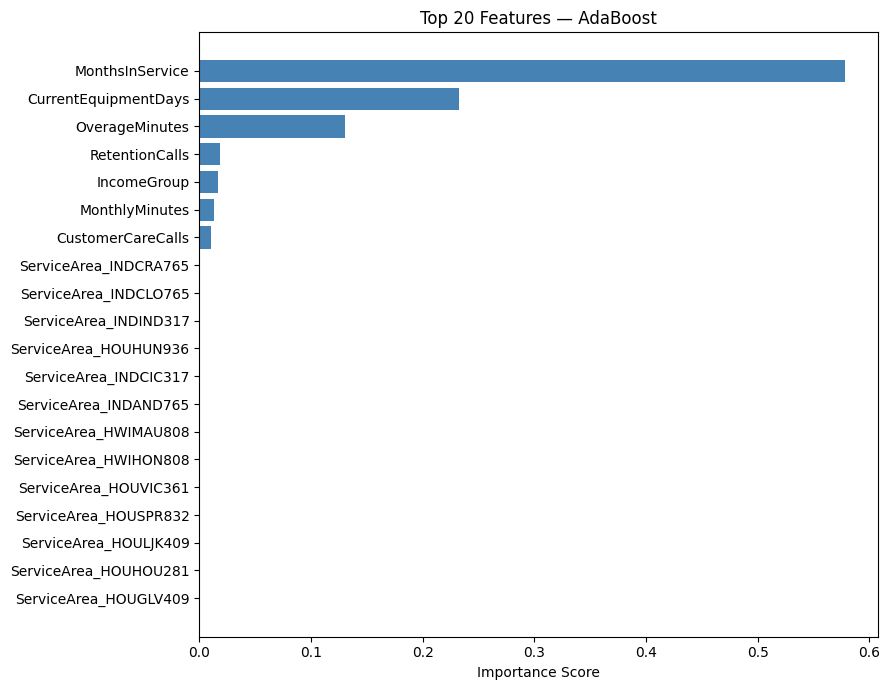

{'best_feature_group': 'Selected Features',
 'cv_metrics': {'train_acc': 0.5950486838467918,
  'val_acc': 0.48326294803134423,
  'precision': 0.33375915114972654,
  'recall': 0.7950527914797032,
  'f1': 0.4700459117396253,
  'roc_auc': 0.6021366947147276},
 'test_metrics': {'accuracy': 0.45,
  'precision': 0.2827968155070959,
  'recall': 0.7288135593220338,
  'f1': 0.40748129675810474,
  'roc_auc': np.float64(0.5724245059855068)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0      Selected Features      0.483263   0.333759  0.795053  0.470046   
 1       Service Features      0.426549   0.319823  0.878494  0.468928   
 2           All Features      0.515807   0.340857  0.728270  0.464330   
 3     Equipment Features      0.543478   0.349902  0.680857  0.462246   
 4           Demographics      0.401817   0.302931  0.826748  0.443394   
 5  Call Quality Features      0.506722   0.308567  0.573111  0.400885   
 6      Behavior Features    

In [ ]:
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=.1,
    random_state=RANDOM_STATE
)

run_baseline_model(model, "AdaBoost")

## 13. Baseline Model: XGBoost

MODEL: XGBoost

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.540025   0.347774 0.680261 0.460221 0.610010
     Service Features      0.550457   0.339547 0.590110 0.430641 0.600767
    Behavior Features      0.452604   0.293768 0.640498 0.401780 0.512694
       Usage Features      0.682493   0.412502 0.236298 0.300226 0.590482
    Selected Features      0.701129   0.458951 0.209022 0.287075 0.642826
Call Quality Features      0.644024   0.321314 0.211996 0.255316 0.531563
         Demographics      0.648358   0.326392 0.205966 0.252235 0.531252
         All Features      0.714058   0.514405 0.138498 0.218192 0.664973

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (XGBoost, 'Equipment Features'):
  accuracy: 0.5769
  precision: 0.2958
  recall: 0.4567
  f1: 0.3590
  roc_auc: 0.5599

Classification Report (Held-out Test Set) — XGBoost
----------

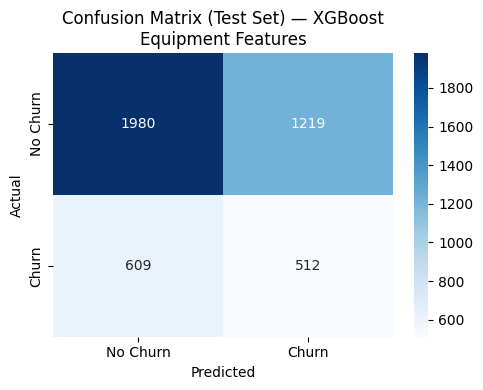

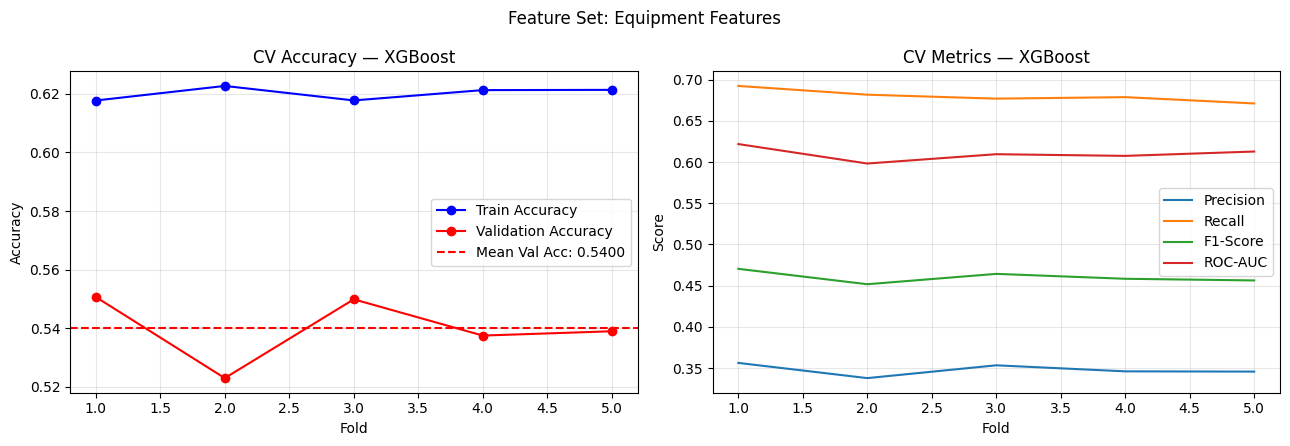

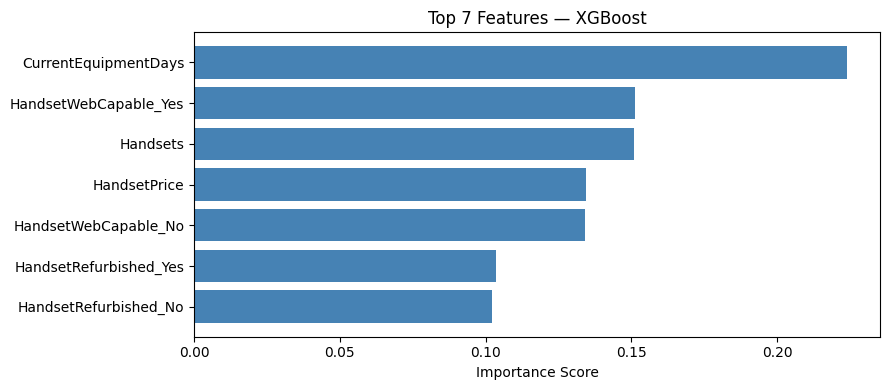

{'best_feature_group': 'Equipment Features',
 'cv_metrics': {'train_acc': 0.6201535854950416,
  'val_acc': 0.5400251327965546,
  'precision': 0.34777439340455557,
  'recall': 0.6802614280437382,
  'f1': 0.4602205047795499,
  'roc_auc': 0.6100097090706125},
 'test_metrics': {'accuracy': 0.5768518518518518,
  'precision': 0.29578278451761986,
  'recall': 0.4567350579839429,
  'f1': 0.3590462833099579,
  'roc_auc': np.float64(0.5599226899351631)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0     Equipment Features      0.540025   0.347774  0.680261  0.460221   
 1       Service Features      0.550457   0.339547  0.590110  0.430641   
 2      Behavior Features      0.452604   0.293768  0.640498  0.401780   
 3         Usage Features      0.682493   0.412502  0.236298  0.300226   
 4      Selected Features      0.701129   0.458951  0.209022  0.287075   
 5  Call Quality Features      0.644024   0.321314  0.211996  0.255316   
 6           De

In [ ]:
xgb_params = dict(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
)
if USE_GPU:
    xgb_params.update(tree_method='hist', device='cuda')

model = XGBClassifier(**xgb_params)

run_baseline_model(model, "XGBoost")

## 14. Baseline Model: CatBoost

MODEL: CatBoost

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.524231   0.345739 0.729373 0.469086 0.612557
     Service Features      0.544433   0.341045 0.619250 0.439011 0.604425
    Behavior Features      0.477680   0.297610 0.596395 0.396385 0.519725
       Usage Features      0.681294   0.413534 0.252952 0.313786 0.596095
         Demographics      0.651909   0.328545 0.198998 0.247854 0.536923
Call Quality Features      0.657982   0.332446 0.185572 0.238130 0.536267
    Selected Features      0.705022   0.464337 0.151839 0.228747 0.642661
         All Features      0.716287   0.543572 0.099413 0.168045 0.658363

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (CatBoost, 'Equipment Features'):
  accuracy: 0.5574
  precision: 0.3012
  recall: 0.5343
  f1: 0.3852
  roc_auc: 0.5704

Classification Report (Held-out Test Set) — CatBoost
-------

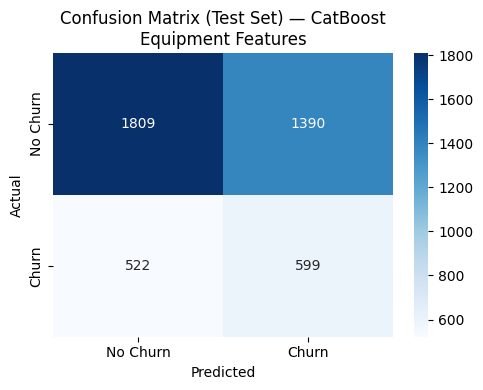

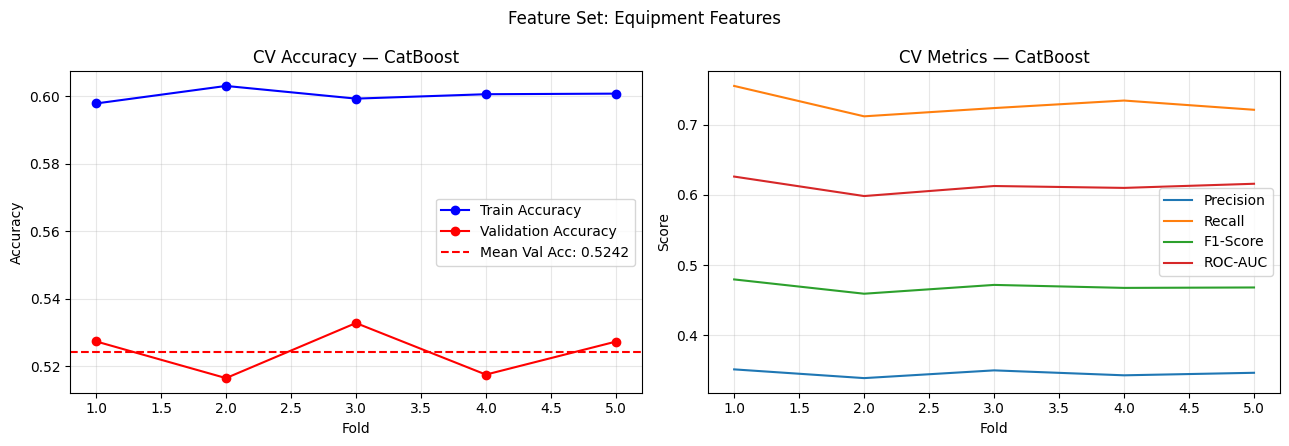

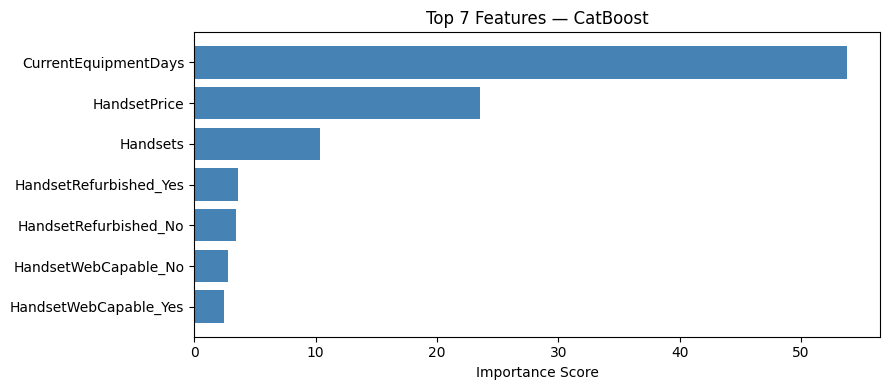

{'best_feature_group': 'Equipment Features',
 'cv_metrics': {'train_acc': 0.6003809967742954,
  'val_acc': 0.5242305936782208,
  'precision': 0.34573917222297645,
  'recall': 0.7293733013514085,
  'f1': 0.46908567477044477,
  'roc_auc': 0.6125574664100879},
 'test_metrics': {'accuracy': 0.5574074074074075,
  'precision': 0.3011563599798894,
  'recall': 0.5343443354148082,
  'f1': 0.3852090032154341,
  'roc_auc': np.float64(0.5703767262238227)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0     Equipment Features      0.524231   0.345739  0.729373  0.469086   
 1       Service Features      0.544433   0.341045  0.619250  0.439011   
 2      Behavior Features      0.477680   0.297610  0.596395  0.396385   
 3         Usage Features      0.681294   0.413534  0.252952  0.313786   
 4           Demographics      0.651909   0.328545  0.198998  0.247854   
 5  Call Quality Features      0.657982   0.332446  0.185572  0.238130   
 6      Selecte

In [ ]:
catboost_params = dict(
    iterations=250,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=0,
)
if USE_GPU:
    catboost_params.update(task_type='GPU', devices='0')

model = CatBoostClassifier(**catboost_params)

run_baseline_model(model, "CatBoost")

## 17. SHAP Explanations for CatBoost Model

This section generates SHAP (SHapley Additive exPlanations) values for the best-performing CatBoost model, providing insights into feature importance and their impact on predictions.

In [ ]:
pip install shap -q

Generated SHAP values for Equipment Features using 1000 samples.


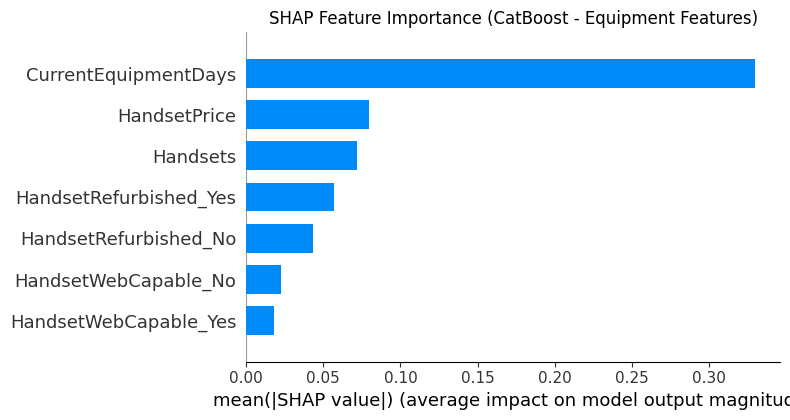

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Retrieve the best CatBoost model configuration and feature group
catboost_results = ALL_MODEL_RESULTS['CatBoost']
best_feature_group_name = catboost_results['best_feature_group']

# Get the original feature list for the best group
best_feature_list = FEATURE_GROUPS[best_feature_group_name]

# Filter the original X_trainval and X_test with the best features
X_trainval_best = filter_features(X_trainval, best_feature_list)
X_test_best = filter_features(X_test, best_feature_list)

# Recreate and fit the preprocessor
num_cols, cat_cols = get_column_types(X_trainval_best)
catboost_preprocessor = create_preprocessor(num_cols, cat_cols)

# Fit the preprocessor on the training data
X_trainval_processed = catboost_preprocessor.fit_transform(X_trainval_best)

# Apply balancing (same logic as in run_baseline_model)
X_trainval_bal, y_trainval_bal = apply_balancing(X_trainval_processed, y_trainval, method=BALANCING_METHOD)

# Recreate and fit the CatBoost model
catboost_params = dict(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=0,
)
if USE_GPU:
    catboost_params.update(task_type='GPU', devices='0')

catboost_model = CatBoostClassifier(**catboost_params)
catboost_model.fit(X_trainval_bal, y_trainval_bal)

# Get processed feature names using the fitted preprocessor
feature_names = get_transformed_feature_names(catboost_preprocessor, num_cols, cat_cols)

# Transform the test data using the *fitted* preprocessor
X_test_processed = catboost_preprocessor.transform(X_test_best)

# Convert to DataFrame for SHAP, ensure column names are correct
if isinstance(X_test_processed, np.ndarray):
    X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)
else:
    X_test_processed_df = X_test_processed

# Create a SHAP explainer for the CatBoost model
# Use a subset of the data for faster computation if the dataset is large
sample_size = min(1000, X_test_processed_df.shape[0])
sampled_X_test_processed = shap.utils.sample(X_test_processed_df, sample_size, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(sampled_X_test_processed)

print(f"Generated SHAP values for {best_feature_group_name} using {sample_size} samples.")

# Visualize the SHAP summary plot
shap.summary_plot(shap_values, sampled_X_test_processed, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance (CatBoost - {best_feature_group_name})')
plt.tight_layout()
plt.show()

# You can also visualize individual predictions (e.g., for the first instance)
# shap.initjs()
# shap.force_plot(explainer.expected_value, shap_values[0,:], sampled_X_test_processed.iloc[0,:])

## 15. Baseline Model: Linear SVC

MODEL: SVC (RBF Kernel)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
       Usage Features      0.431031   0.292641 0.687826 0.410383 0.483975
Call Quality Features      0.439039   0.294663 0.678903 0.409564 0.494649
         All Features      0.430786   0.290078 0.672958 0.404824 0.492619
    Selected Features      0.457772   0.291172 0.614416 0.394023 0.503995
   Equipment Features      0.442688   0.279954 0.598106 0.380436 0.487120
         Demographics      0.568136   0.282682 0.323999 0.298361 0.504587
     Service Features      0.571145   0.302633 0.353356 0.272882 0.509299
    Behavior Features      0.625165   0.279098 0.201787 0.141431 0.501604

Best feature group by CV F1: 'Usage Features'

Final test-set performance (SVC (RBF Kernel), 'Usage Features'):
  accuracy: 0.4366
  precision: 0.2666
  recall: 0.6690
  f1: 0.3813
  roc_auc: 0.4857

Classification Report (Held-out Test Set) — SVC (RBF

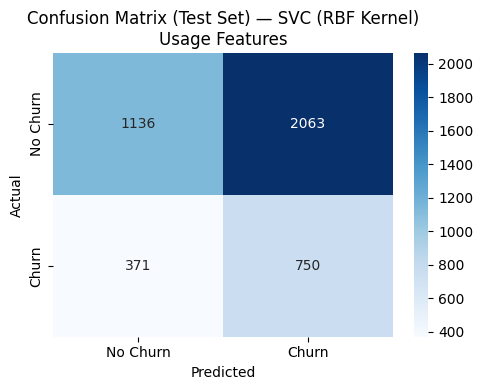

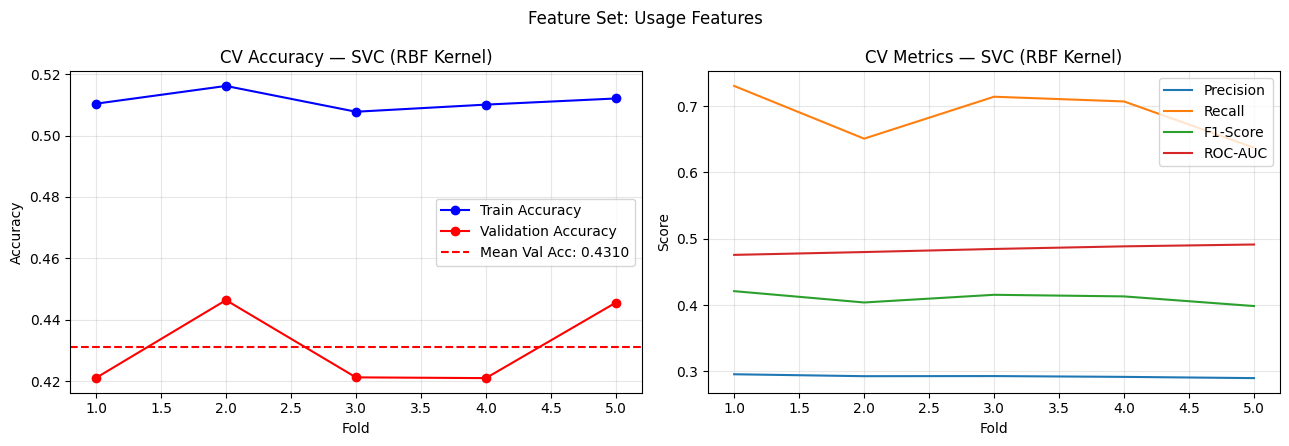

No feature importance available for SVC (RBF Kernel)


{'best_feature_group': 'Usage Features',
 'cv_metrics': {'train_acc': 0.5113182918183765,
  'val_acc': 0.4310305519921013,
  'precision': 0.2926412985015693,
  'recall': 0.6878261667077694,
  'f1': 0.4103830323255296,
  'roc_auc': 0.48397489525739673},
 'test_metrics': {'accuracy': 0.43657407407407406,
  'precision': 0.26661926768574473,
  'recall': 0.6690454950936664,
  'f1': 0.3812913065582105,
  'roc_auc': np.float64(0.4856923118536987)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0         Usage Features      0.431031   0.292641  0.687826  0.410383   
 1  Call Quality Features      0.439039   0.294663  0.678903  0.409564   
 2           All Features      0.430786   0.290078  0.672958  0.404824   
 3      Selected Features      0.457772   0.291172  0.614416  0.394023   
 4     Equipment Features      0.442688   0.279954  0.598106  0.380436   
 5           Demographics      0.568136   0.282682  0.323999  0.298361   
 6       Service F

In [ ]:
# LinearSVC has no predict_proba; run_baseline_model falls back to decision_function for ROC-AUC.
# Changed to SVC to support 'rbf' kernel.
from sklearn.svm import SVC

model = SVC(
    C=1.0,
    kernel='rbf',
    max_iter=500, # Increased max_iter for SVC
    random_state=RANDOM_STATE,
    probability=True # Required for predict_proba
)

run_baseline_model(model, "SVC (RBF Kernel)")

## 15.1 Baseline Model: SVC (Linear Kernel)

MODEL: SVC (Linear Kernel)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.301883   0.289563 0.978159 0.446775 0.511961
Call Quality Features      0.302618   0.289550 0.976719 0.446678 0.475560
    Behavior Features      0.301908   0.289451 0.977653 0.446660 0.475606
       Usage Features      0.291917   0.287787 0.987933 0.445726 0.506803
         All Features      0.311115   0.289721 0.957684 0.444840 0.479869
    Selected Features      0.328868   0.290890 0.924126 0.442384 0.495944
         Demographics      0.450278   0.291957 0.634467 0.397635 0.492223
     Service Features      0.595610   0.285424 0.275540 0.223641 0.492551

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (SVC (Linear Kernel), 'Equipment Features'):
  accuracy: 0.2743
  precision: 0.2605
  recall: 0.9768
  f1: 0.4113
  roc_auc: 0.5234

Classification Report (Held-out Test S

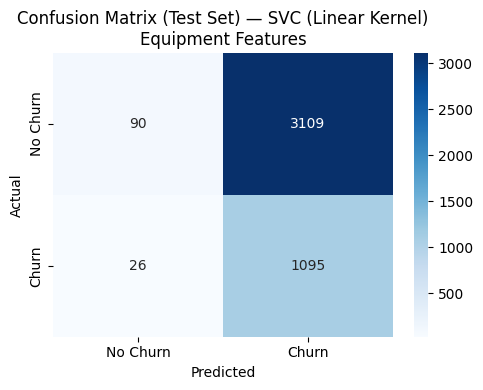

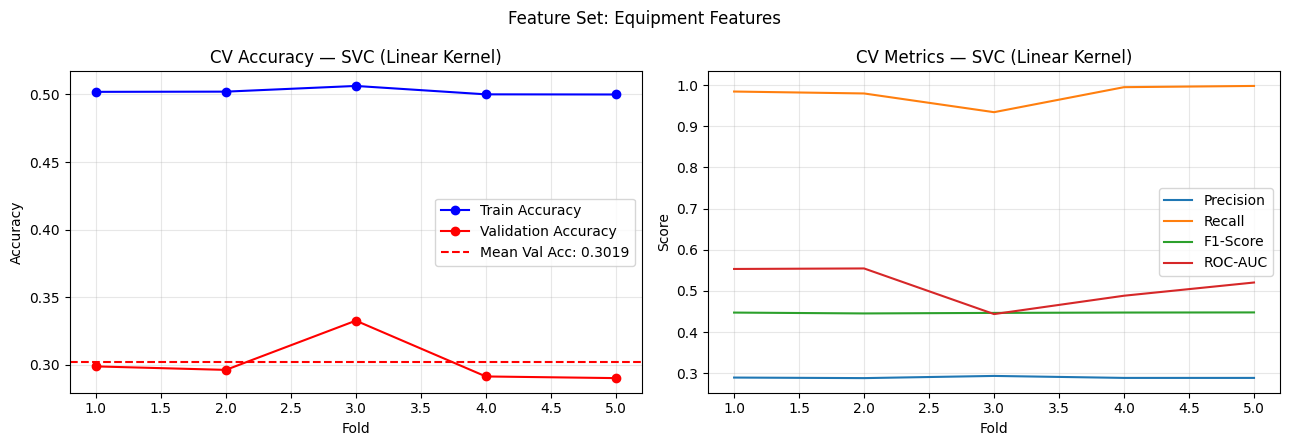

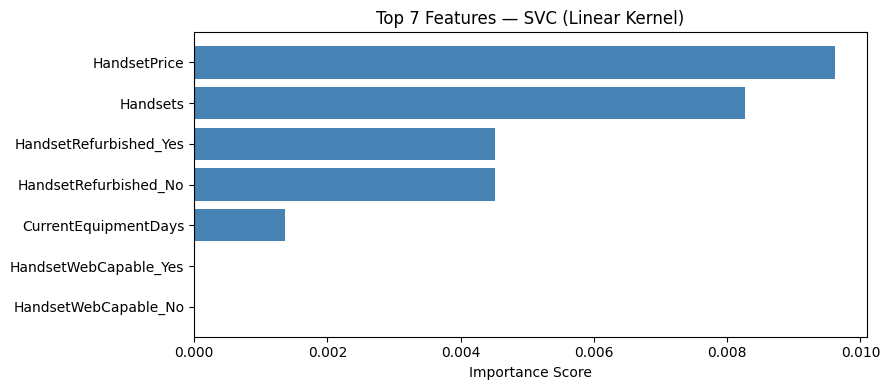

{'best_feature_group': 'Equipment Features',
 'cv_metrics': {'train_acc': 0.5020340588414961,
  'val_acc': 0.3018833077672058,
  'precision': 0.2895631923819023,
  'recall': 0.9781592291118806,
  'f1': 0.44677521090295935,
  'roc_auc': 0.511961307831389},
 'test_metrics': {'accuracy': 0.2743055555555556,
  'precision': 0.2604662226450999,
  'recall': 0.9768064228367529,
  'f1': 0.4112676056338028,
  'roc_auc': np.float64(0.5234214025959829)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0     Equipment Features      0.301883   0.289563  0.978159  0.446775   
 1  Call Quality Features      0.302618   0.289550  0.976719  0.446678   
 2      Behavior Features      0.301908   0.289451  0.977653  0.446660   
 3         Usage Features      0.291917   0.287787  0.987933  0.445726   
 4           All Features      0.311115   0.289721  0.957684  0.444840   
 5      Selected Features      0.328868   0.290890  0.924126  0.442384   
 6           Demo

In [ ]:
from sklearn.svm import SVC

model = SVC(
    C=.01,
    kernel='linear',
    max_iter=500, # Increased max_iter for SVC
    random_state=RANDOM_STATE,
    probability=True # Required for predict_proba
)

run_baseline_model(model, "SVC (Linear Kernel)")

## 15.2 Baseline Model: SVC (Polynomial Kernel)

MODEL: SVC (Polynomial Kernel)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
    Behavior Features      0.290129   0.288525 0.998131 0.447650 0.478014
   Equipment Features      0.288464   0.288200 0.999405 0.447386 0.497391
Call Quality Features      0.289370   0.288274 0.997876 0.447322 0.480859
     Service Features      0.288954   0.288143 0.997791 0.447156 0.501950
         All Features      0.289958   0.288205 0.995922 0.447042 0.489966
    Selected Features      0.291011   0.288186 0.993288 0.446753 0.503952
       Usage Features      0.290913   0.288159 0.993288 0.446720 0.512996
         Demographics      0.304258   0.289520 0.972385 0.446169 0.484325

Best feature group by CV F1: 'Behavior Features'

Final test-set performance (SVC (Polynomial Kernel), 'Behavior Features'):
  accuracy: 0.2757
  precision: 0.2614
  recall: 0.9813
  f1: 0.4128
  roc_auc: 0.4719

Classification Report (Held-out 

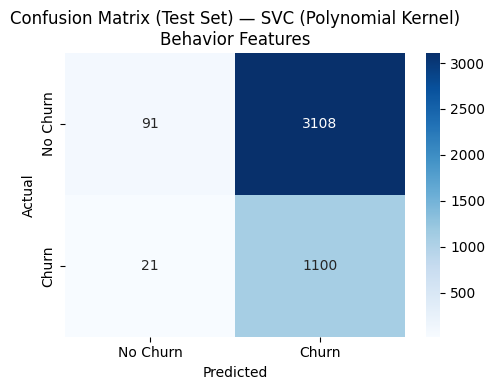

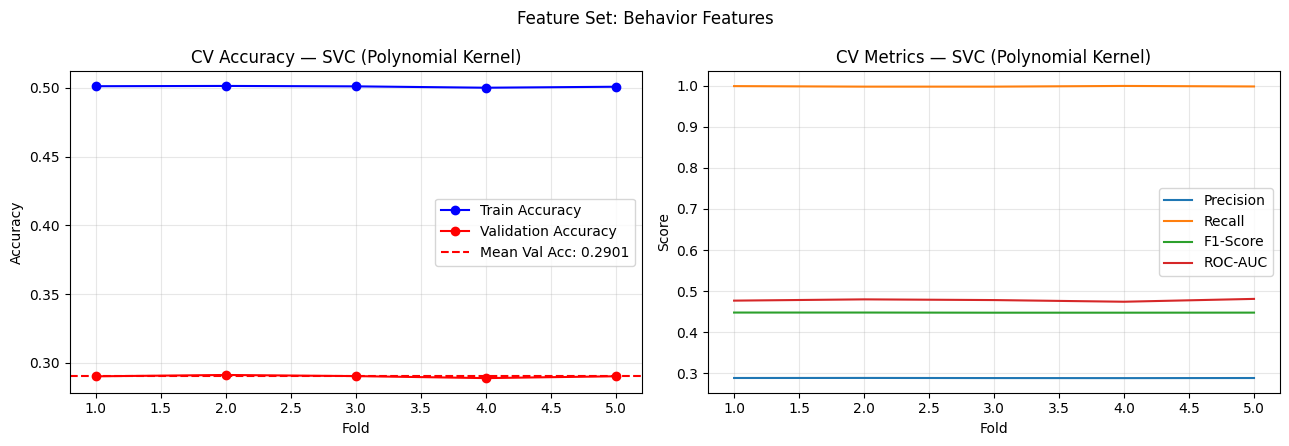

No feature importance available for SVC (Polynomial Kernel)


{'best_feature_group': 'Behavior Features',
 'cv_metrics': {'train_acc': 0.5010105693941826,
  'val_acc': 0.2901290242965557,
  'precision': 0.288524950843558,
  'recall': 0.998130624474405,
  'f1': 0.44764976717002974,
  'roc_auc': 0.47801430406356565},
 'test_metrics': {'accuracy': 0.27569444444444446,
  'precision': 0.26140684410646386,
  'recall': 0.9812667261373773,
  'f1': 0.4128354287858885,
  'roc_auc': np.float64(0.4718839155523344)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0      Behavior Features      0.290129   0.288525  0.998131  0.447650   
 1     Equipment Features      0.288464   0.288200  0.999405  0.447386   
 2  Call Quality Features      0.289370   0.288274  0.997876  0.447322   
 3       Service Features      0.288954   0.288143  0.997791  0.447156   
 4           All Features      0.289958   0.288205  0.995922  0.447042   
 5      Selected Features      0.291011   0.288186  0.993288  0.446753   
 6         Usage

In [ ]:
from sklearn.svm import SVC

model = SVC(
    C=.1,
    kernel='poly',
    degree=3, # Degree for polynomial kernel
    max_iter=1000, # Increased max_iter for SVC
    random_state=RANDOM_STATE,
    probability=True # Required for predict_proba
)

run_baseline_model(model, "SVC (Polynomial Kernel)")

## 16. Baseline Model: MLP (Neural Network)

MODEL: MLP (Neural Network)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.507114   0.341350 0.762681 0.471536 0.584650
         All Features      0.579009   0.357077 0.577704 0.441108 0.602668
    Behavior Features      0.358597   0.291711 0.857592 0.434503 0.503298
       Usage Features      0.548204   0.338240 0.593764 0.430851 0.583536
         Demographics      0.470089   0.307599 0.670147 0.421487 0.539767
    Selected Features      0.576046   0.346337 0.531134 0.418552 0.585325
Call Quality Features      0.552635   0.305151 0.430617 0.354205 0.526543
     Service Features      0.604428   0.316411 0.319141 0.317134 0.523451

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (MLP (Neural Network), 'Equipment Features'):
  accuracy: 0.5144
  precision: 0.2953
  recall: 0.6289
  f1: 0.4019
  roc_auc: 0.5632

Classification Report (Held-out Test

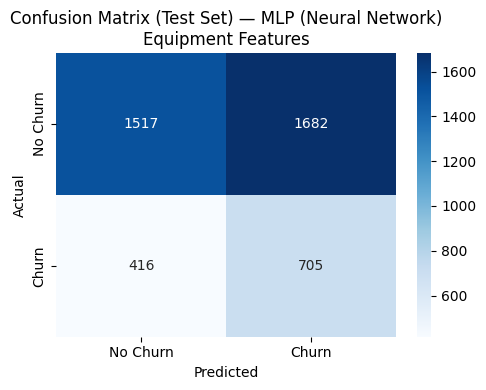

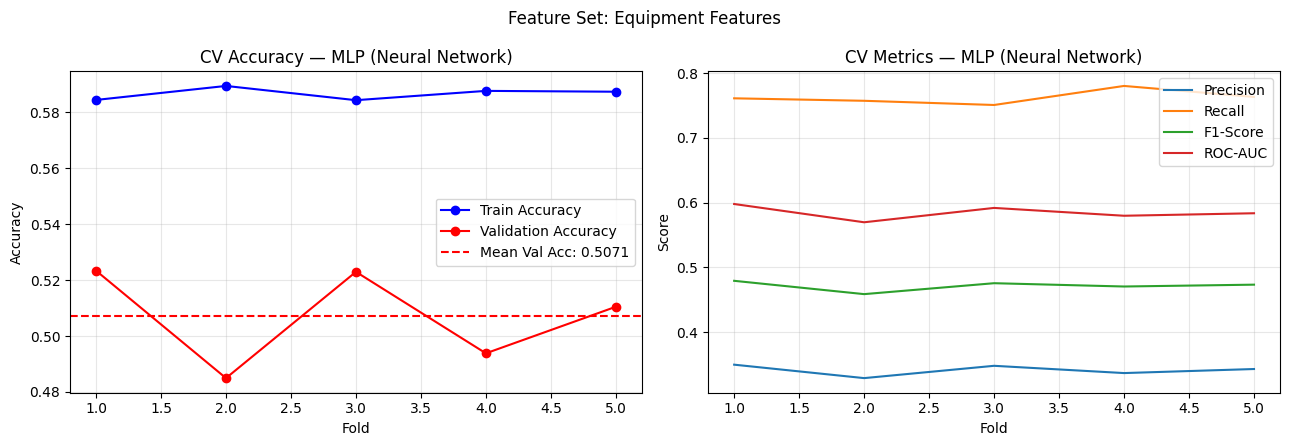

No feature importance available for MLP (Neural Network)


{'best_feature_group': 'Equipment Features',
 'cv_metrics': {'train_acc': 0.5866803551893991,
  'val_acc': 0.5071137914737015,
  'precision': 0.34134992161149225,
  'recall': 0.7626806249979688,
  'f1': 0.47153590783924565,
  'roc_auc': 0.5846495325223656},
 'test_metrics': {'accuracy': 0.5143518518518518,
  'precision': 0.29534981147884376,
  'recall': 0.6289027653880463,
  'f1': 0.40193842645381983,
  'roc_auc': np.float64(0.5632338272525508)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0     Equipment Features      0.507114   0.341350  0.762681  0.471536   
 1           All Features      0.579009   0.357077  0.577704  0.441108   
 2      Behavior Features      0.358597   0.291711  0.857592  0.434503   
 3         Usage Features      0.548204   0.338240  0.593764  0.430851   
 4           Demographics      0.470089   0.307599  0.670147  0.421487   
 5      Selected Features      0.576046   0.346337  0.531134  0.418552   
 6  Call Qual

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(4, 4),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='constant',
    learning_rate_init=0.0005,
    max_iter=100,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

run_baseline_model(model, "MLP (Neural Network)")

MODEL: MLP (Neural Network)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
         Demographics      0.288195   0.288195 1.000000 0.447439 0.486454
   Equipment Features      0.533120   0.339463 0.655282 0.447211 0.579528
         All Features      0.580062   0.357431 0.573026 0.439769 0.611553
    Selected Features      0.574920   0.354314 0.576259 0.438701 0.603835
    Behavior Features      0.396845   0.293850 0.777805 0.425876 0.515235
       Usage Features      0.547200   0.333548 0.572433 0.421073 0.571622
Call Quality Features      0.420207   0.295359 0.729799 0.420500 0.516858
     Service Features      0.563898   0.314169 0.427824 0.347095 0.526152

Best feature group by CV F1: 'Demographics'

Final test-set performance (MLP (Neural Network), 'Demographics'):
  accuracy: 0.2595
  precision: 0.2595
  recall: 1.0000
  f1: 0.4121
  roc_auc: 0.4882

Classification Report (Held-out Test Set) — MLP 

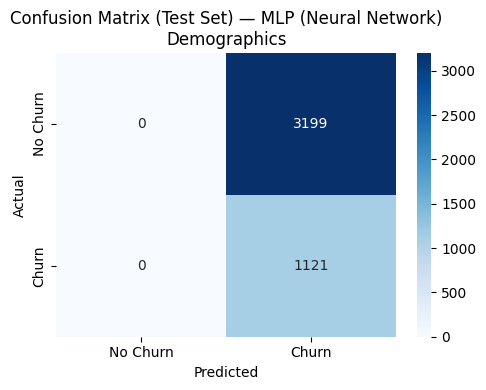

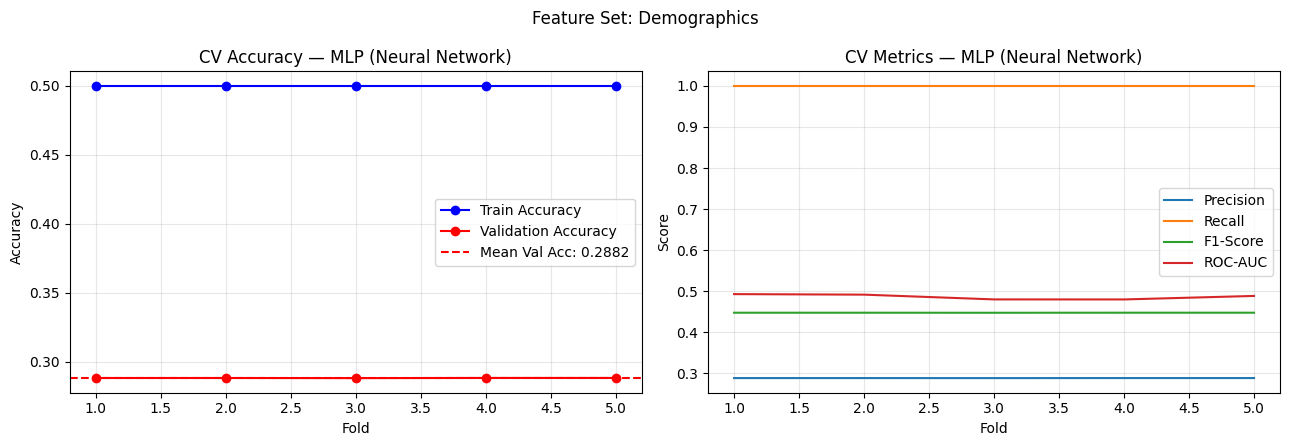

No feature importance available for MLP (Neural Network)


{'best_feature_group': 'Demographics',
 'cv_metrics': {'train_acc': 0.5,
  'val_acc': 0.28819452930842415,
  'precision': 0.28819452930842415,
  'recall': 1.0,
  'f1': 0.4474394535025076,
  'roc_auc': 0.486453924797474},
 'test_metrics': {'accuracy': 0.25949074074074074,
  'precision': 0.25949074074074074,
  'recall': 1.0,
  'f1': 0.41205660724131593,
  'roc_auc': np.float64(0.48822627722367523)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0           Demographics      0.288195   0.288195  1.000000  0.447439   
 1     Equipment Features      0.533120   0.339463  0.655282  0.447211   
 2           All Features      0.580062   0.357431  0.573026  0.439769   
 3      Selected Features      0.574920   0.354314  0.576259  0.438701   
 4      Behavior Features      0.396845   0.293850  0.777805  0.425876   
 5         Usage Features      0.547200   0.333548  0.572433  0.421073   
 6  Call Quality Features      0.420207   0.295359  0.729799  0

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(4),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='constant',
    learning_rate_init=.0001,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

run_baseline_model(model, "MLP (Neural Network)")

MODEL: MLP (Neural Network, resized)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.515929   0.342974 0.740331 0.468497 0.606789
     Service Features      0.519920   0.333749 0.663870 0.442023 0.597927
       Usage Features      0.583515   0.350550 0.521622 0.418946 0.591223
    Behavior Features      0.473566   0.299561 0.612948 0.397330 0.520260
Call Quality Features      0.536962   0.313268 0.505053 0.383762 0.536511
         Demographics      0.519261   0.302795 0.512192 0.379955 0.514626
         All Features      0.633862   0.354244 0.329422 0.340968 0.574901
    Selected Features      0.629209   0.346242 0.322628 0.333864 0.563697

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (MLP (Neural Network, resized), 'Equipment Features'):
  accuracy: 0.5637
  precision: 0.3033
  recall: 0.5254
  f1: 0.3846
  roc_auc: 0.5634

Classification Rep

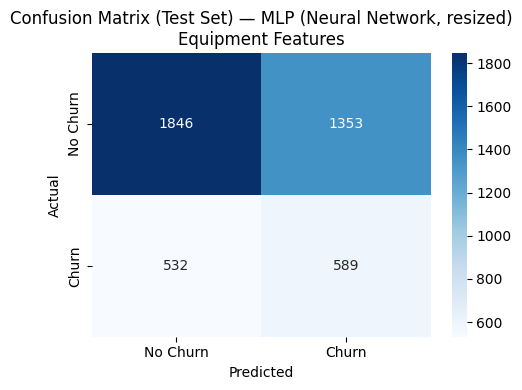

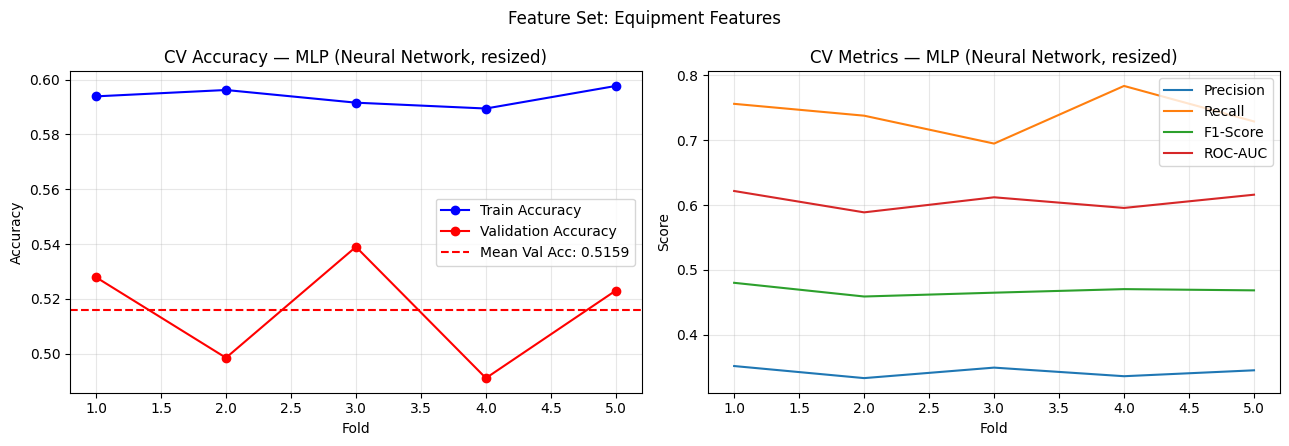

No feature importance available for MLP (Neural Network, resized)


{'best_feature_group': 'Equipment Features',
 'cv_metrics': {'train_acc': 0.5937758049019459,
  'val_acc': 0.5159293144444204,
  'precision': 0.3429739486731367,
  'recall': 0.7403309139871332,
  'f1': 0.46849731209796114,
  'roc_auc': 0.6067894886611035},
 'test_metrics': {'accuracy': 0.5636574074074074,
  'precision': 0.30329557157569514,
  'recall': 0.5254237288135594,
  'f1': 0.38459027097616716,
  'roc_auc': np.float64(0.5633862221105559)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0     Equipment Features      0.515929   0.342974  0.740331  0.468497   
 1       Service Features      0.519920   0.333749  0.663870  0.442023   
 2         Usage Features      0.583515   0.350550  0.521622  0.418946   
 3      Behavior Features      0.473566   0.299561  0.612948  0.397330   
 4  Call Quality Features      0.536962   0.313268  0.505053  0.383762   
 5           Demographics      0.519261   0.302795  0.512192  0.379955   
 6           A

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # was (4, 4) — far too small for 54 input features
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,                  # was 100
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)

run_baseline_model(model, "MLP (Neural Network, resized)")

MODEL: Random Forest (regularized)

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.519627   0.345887 0.748321 0.473094 0.614609
    Selected Features      0.583148   0.363415 0.592829 0.450532 0.619919
     Service Features      0.502117   0.331750 0.711611 0.450511 0.605770
         Demographics      0.496878   0.308457 0.600473 0.407427 0.543848
         All Features      0.638220   0.384612 0.425014 0.403745 0.619735
    Behavior Features      0.499988   0.299537 0.545925 0.383419 0.519434
       Usage Features      0.612900   0.354719 0.417537 0.383372 0.580173
Call Quality Features      0.591547   0.318884 0.367492 0.341239 0.535618

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (Random Forest (regularized), 'Equipment Features'):
  accuracy: 0.5465
  precision: 0.3057
  recall: 0.5879
  f1: 0.4022
  roc_auc: 0.5778

Classification Report 

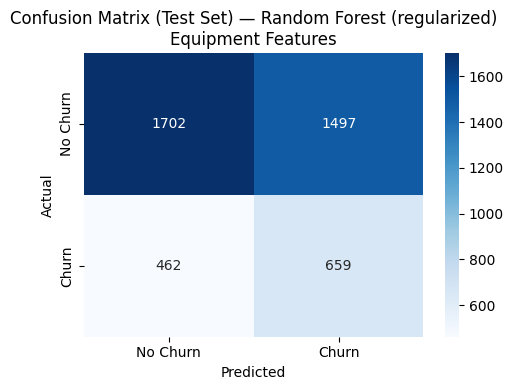

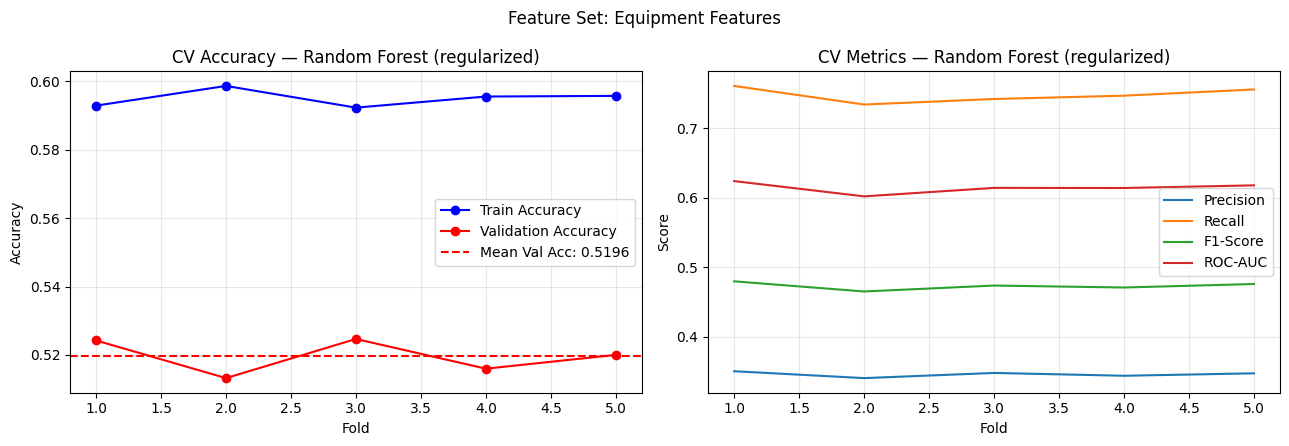

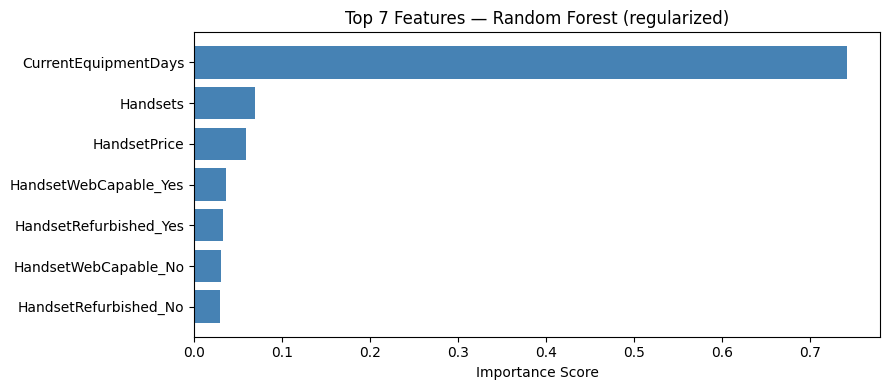

{'best_feature_group': 'Equipment Features',
 'cv_metrics': {'train_acc': 0.5950701696207255,
  'val_acc': 0.5196268528646676,
  'precision': 0.34588670514993164,
  'recall': 0.7483213641833976,
  'f1': 0.473093525415221,
  'roc_auc': 0.614608753299204},
 'test_metrics': {'accuracy': 0.5465277777777777,
  'precision': 0.30565862708719854,
  'recall': 0.5878679750223015,
  'f1': 0.40219713152273423,
  'roc_auc': np.float64(0.5777795190791949)},
 'ablation_table':            Feature Group  Val Accuracy  Precision    Recall        F1  \
 0     Equipment Features      0.519627   0.345887  0.748321  0.473094   
 1      Selected Features      0.583148   0.363415  0.592829  0.450532   
 2       Service Features      0.502117   0.331750  0.711611  0.450511   
 3           Demographics      0.496878   0.308457  0.600473  0.407427   
 4           All Features      0.638220   0.384612  0.425014  0.403745   
 5      Behavior Features      0.499988   0.299537  0.545925  0.383419   
 6         Usage

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,              # was None — unlimited depth was memorizing SMOTE points
    min_samples_split=10,
    min_samples_leaf=20,      # was 1 — forces leaves to cover real, not synthetic, clusters
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

run_baseline_model(model, "Random Forest (regularized)")

In [ ]:
model_cw = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

run_baseline_model(model_cw, "Random Forest (class_weight, no SMOTE)", balancing_method='none')

In [ ]:
xgb_params = dict(
    n_estimators=500,
    max_depth=3,              # was 6 — shallower trees generalize better here
    learning_rate=0.03,       # was 0.1 — slower learning paired with more rounds + early stop
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,            # was 0.0 — add L1
    reg_lambda=2.0,           # was 1.0 — stronger L2
    min_child_weight=5,       # new — resist splitting on tiny/synthetic clusters
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30,
)
if USE_GPU:
    xgb_params.update(tree_method='hist', device='cuda')

model = XGBClassifier(**xgb_params)

# NOTE: run_baseline_model's train_and_evaluate_cv/evaluate_on_test don't pass
# eval_set, so early_stopping_rounds won't trigger inside those helpers as-is.
# Simplest fix: drop early_stopping_rounds from xgb_params above for the
# run_baseline_model() call, and use the manual block below instead for a
# properly early-stopped final fit/eval.

run_baseline_model(model, "XGBoost (regularized)")

In [ ]:
from sklearn.model_selection import train_test_split as tts

X_fit, X_es, y_fit, y_es = tts(X_trainval, y_trainval, test_size=0.15,
                                stratify=y_trainval, random_state=RANDOM_STATE)

num_cols, cat_cols = get_column_types(X_fit)
prep = create_preprocessor(num_cols, cat_cols)
X_fit_proc = prep.fit_transform(X_fit)
X_es_proc = prep.transform(X_es)
X_test_proc = prep.transform(filter_features(X_test, X_fit.columns.tolist()))

X_fit_bal, y_fit_bal = apply_balancing(X_fit_proc, y_fit)

xgb_params_es = dict(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    min_child_weight=5,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30,
)
if USE_GPU:
    xgb_params_es.update(tree_method='hist', device='cuda')

xgb_es_model = XGBClassifier(**xgb_params_es)
xgb_es_model.fit(X_fit_bal, y_fit_bal, eval_set=[(X_es_proc, y_es)], verbose=False)

y_pred = xgb_es_model.predict(X_test_proc)
y_scores = xgb_es_model.predict_proba(X_test_proc)[:, 1]
print(f"XGBoost (early-stopped) best_iteration: {xgb_es_model.best_iteration}")
print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_scores))

XGBoost (early-stopped) best_iteration: 998
accuracy: 0.743287037037037
precision: 0.5348837209302325
recall: 0.08206958073148975
f1: 0.1423047177107502
roc_auc: 0.660737953625673


## SVC

In [ ]:

from sklearn.svm import SVC

model = SVC(
    C=1.0,
    kernel='rbf',
    max_iter=5000, # Increased max_iter for SVC
    random_state=RANDOM_STATE,
    probability=True # Required for predict_proba
)

run_baseline_model(model, "SVC (RBF Kernel)")

NameError: name 'RANDOM_STATE' is not defined

## 17. Baseline Model: MLP (Neural Network) with Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the MLPClassifier base model
mlp_base_model = MLPClassifier(
    max_iter=200, # Increased max_iter for tuning
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

# Define the hyperparameter space to search
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50, 25)], # Explore different architectures
    'activation': ['relu', 'tanh'], # Explore different activation functions
    'solver': ['adam', 'sgd'], # Explore different solvers
    'alpha': [0.0001, 0.001, 0.01, 0.1], # Explore different L2 regularization strengths
    'learning_rate_init': [0.001, 0.005, 0.01, 0.05] # Explore different initial learning rates
}

# Set up RandomizedSearchCV
# n_iter: number of parameter settings that are sampled. (Adjust as needed for computational budget)
# cv: number of cross-validation folds
# scoring: metric to optimize (F1-score for imbalanced datasets)
# n_jobs: use all available cores
random_search = RandomizedSearchCV(
    estimator=mlp_base_model,
    param_distributions=param_dist,
    n_iter=20, # Reduced for a lightweight search, increase if more thorough search is needed
    cv=3, # Reduced for lightweight search, increase for more robust evaluation
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Perform the search on a subset of the data for faster tuning (optional, but good for lightweight models)
# For a full search, remove this sampling and use X_trainval, y_trainval directly.
print("Performing RandomizedSearchCV for MLPClassifier...")

# The run_baseline_model function handles its own CV, preprocessing, and balancing.
# So, we need to integrate this tuning into the overall flow or tune separately.
# For simplicity, we will fit RandomizedSearchCV on a processed version of the full trainval data
# and then pass the best estimator to run_baseline_model.

# To make this compatible with run_baseline_model's structure, we first need to identify the best features
# and preprocess the data ONCE before tuning if we want to tune the model itself.
# However, the `run_baseline_model` already handles feature group selection and preprocessing within its CV loop.
# Therefore, we will run the `RandomizedSearchCV` on a specific feature group and then let `run_baseline_model` re-evaluate it.
# For consistency with other models, we will pick 'All Features' for the initial tuning, but the `run_baseline_model`
# will still perform its ablation study.

print("Note: RandomizedSearchCV will be performed on 'All Features' initially to find best hyperparameters.")
print("The `run_baseline_model` will then re-evaluate this best model across all feature groups.")

# Identify best features and preprocess for tuning. For an initial tune, we'll use 'All Features'.
X_trainval_for_tune = filter_features(X_trainval, FEATURE_GROUPS['All Features'])
num_cols_tune, cat_cols_tune = get_column_types(X_trainval_for_tune)
preprocessor_tune = create_preprocessor(num_cols_tune, cat_cols_tune)

X_trainval_proc_for_tune = preprocessor_tune.fit_transform(X_trainval_for_tune)
X_trainval_bal_for_tune, y_trainval_bal_for_tune = apply_balancing(X_trainval_proc_for_tune, y_trainval, method=BALANCING_METHOD)

# Perform the randomized search
random_search.fit(X_trainval_bal_for_tune, y_trainval_bal_for_tune)

print("RandomizedSearchCV completed.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best F1 score from CV: {random_search.best_score_:.4f}")

# Get the best model found by RandomizedSearchCV
best_mlp_model = random_search.best_estimator_

# Run the baseline model function with the best estimator found
run_baseline_model(best_mlp_model, "MLP (Tuned Neural Network)")

## ALL Model Results

In [ ]:
"""======================================================================
MODEL: Logistic Regression
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
         All Features      0.578911   0.355330 0.566232 0.436601 0.604777
       Usage Features      0.522198   0.329392 0.635144 0.433800 0.578063
    Selected Features      0.569312   0.346266 0.556801 0.426970 0.590753
Call Quality Features      0.431986   0.300803 0.733113 0.426567 0.533994
    Behavior Features      0.424126   0.296902 0.729118 0.421924 0.524872
         Demographics      0.501628   0.311926 0.604809 0.411540 0.546105
   Equipment Features      0.579205   0.332846 0.457898 0.385459 0.582781
     Service Features      0.594632   0.302103 0.310814 0.306376 0.538291

Best feature group by CV F1: 'All Features'

Final test-set performance (Logistic Regression, 'All Features'):
  accuracy: 0.6271
  precision: 0.3457
  recall: 0.4897
  f1: 0.4053
  roc_auc: 0.6142

Classification Report (Held-out Test Set) — Logistic Regression
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.79      0.68      0.73      3199
       Churn       0.35      0.49      0.41      1121

    accuracy                           0.63      4320
   macro avg       0.57      0.58      0.57      4320
weighted avg       0.68      0.63      0.64      4320



======================================================================
MODEL: Random Forest
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
     Service Features      0.557926   0.340071 0.567084 0.424948 0.593978
    Behavior Features      0.454661   0.293715 0.635650 0.400373 0.511437
   Equipment Features      0.584421   0.340290 0.470812 0.395030 0.556345
         Demographics      0.589588   0.307525 0.339199 0.322448 0.515015
Call Quality Features      0.602125   0.311665 0.315064 0.313345 0.519153
       Usage Features      0.663810   0.374042 0.247175 0.297643 0.571836
    Selected Features      0.695864   0.438444 0.196533 0.271375 0.633317
         All Features      0.706541   0.463844 0.116832 0.186560 0.635617

Best feature group by CV F1: 'Service Features'

Final test-set performance (Random Forest, 'Service Features'):
  accuracy: 0.5352
  precision: 0.3005
  recall: 0.5959
  f1: 0.3995
  roc_auc: 0.5790

Classification Report (Held-out Test Set) — Random Forest
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.78      0.51      0.62      3199
       Churn       0.30      0.60      0.40      1121

    accuracy                           0.54      4320
   macro avg       0.54      0.55      0.51      4320
weighted avg       0.66      0.54      0.56      4320

======================================================================
MODEL: AdaBoost
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
    Selected Features      0.483263   0.333759 0.795053 0.470046 0.602137
     Service Features      0.426549   0.319823 0.878494 0.468928 0.597355
         All Features      0.515807   0.340857 0.728270 0.464330 0.601372
   Equipment Features      0.543478   0.349902 0.680857 0.462246 0.600538
         Demographics      0.401817   0.302931 0.826748 0.443394 0.532845
Call Quality Features      0.506722   0.308567 0.573111 0.400885 0.537061
    Behavior Features      0.474276   0.298776 0.608377 0.398092 0.521368
       Usage Features      0.603129   0.334006 0.377693 0.352979 0.549407

Best feature group by CV F1: 'Selected Features'

Final test-set performance (AdaBoost, 'Selected Features'):
  accuracy: 0.4500
  precision: 0.2828
  recall: 0.7288
  f1: 0.4075
  roc_auc: 0.5724

Classification Report (Held-out Test Set) — AdaBoost
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.79      0.35      0.49      3199
       Churn       0.28      0.73      0.41      1121

    accuracy                           0.45      4320
   macro avg       0.54      0.54      0.45      4320
weighted avg       0.66      0.45      0.47      4320

======================================================================
MODEL: XGBoost
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.540025   0.347774 0.680261 0.460221 0.610010
     Service Features      0.550457   0.339547 0.590110 0.430641 0.600767
    Behavior Features      0.452604   0.293768 0.640498 0.401780 0.512694
       Usage Features      0.682493   0.412502 0.236298 0.300226 0.590482
    Selected Features      0.701129   0.458951 0.209022 0.287075 0.642826
Call Quality Features      0.644024   0.321314 0.211996 0.255316 0.531563
         Demographics      0.648358   0.326392 0.205966 0.252235 0.531252
         All Features      0.714058   0.514405 0.138498 0.218192 0.664973

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (XGBoost, 'Equipment Features'):
  accuracy: 0.5769
  precision: 0.2958
  recall: 0.4567
  f1: 0.3590
  roc_auc: 0.5599

Classification Report (Held-out Test Set) — XGBoost
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.76      0.62      0.68      3199
       Churn       0.30      0.46      0.36      1121

    accuracy                           0.58      4320
   macro avg       0.53      0.54      0.52      4320
weighted avg       0.64      0.58      0.60      4320

======================================================================
MODEL: CatBoost
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.524231   0.345739 0.729373 0.469086 0.612557
     Service Features      0.544433   0.341045 0.619250 0.439011 0.604425
    Behavior Features      0.477680   0.297610 0.596395 0.396385 0.519725
       Usage Features      0.681294   0.413534 0.252952 0.313786 0.596095
         Demographics      0.651909   0.328545 0.198998 0.247854 0.536923
Call Quality Features      0.657982   0.332446 0.185572 0.238130 0.536267
    Selected Features      0.705022   0.464337 0.151839 0.228747 0.642661
         All Features      0.716287   0.543572 0.099413 0.168045 0.658363

Best feature group by CV F1: 'Equipment Features'

Final test-set performance (CatBoost, 'Equipment Features'):
  accuracy: 0.5574
  precision: 0.3012
  recall: 0.5343
  f1: 0.3852
  roc_auc: 0.5704

Classification Report (Held-out Test Set) — CatBoost
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.78      0.57      0.65      3199
       Churn       0.30      0.53      0.39      1121

    accuracy                           0.56      4320
   macro avg       0.54      0.55      0.52      4320
weighted avg       0.65      0.56      0.58      4320


======================================================================
MODEL: SVC (RBF Kernel)
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
       Usage Features      0.431031   0.292641 0.687826 0.410383 0.483975
Call Quality Features      0.439039   0.294663 0.678903 0.409564 0.494649
         All Features      0.430786   0.290078 0.672958 0.404824 0.492619
    Selected Features      0.457772   0.291172 0.614416 0.394023 0.503995
   Equipment Features      0.442688   0.279954 0.598106 0.380436 0.487120
         Demographics      0.568136   0.282682 0.323999 0.298361 0.504587
     Service Features      0.571145   0.302633 0.353356 0.272882 0.509299
    Behavior Features      0.625165   0.279098 0.201787 0.141431 0.501604

Best feature group by CV F1: 'Usage Features'

Final test-set performance (SVC (RBF Kernel), 'Usage Features'):
  accuracy: 0.4366
  precision: 0.2666
  recall: 0.6690
  f1: 0.3813
  roc_auc: 0.4857

Classification Report (Held-out Test Set) — SVC (RBF Kernel)
-------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.75      0.36      0.48      3199
       Churn       0.27      0.67      0.38      1121

    accuracy                           0.44      4320
   macro avg       0.51      0.51      0.43      4320
weighted avg       0.63      0.44      0.46      4320


======================================================================
MODEL: MLP (Neural Network)
======================================================================

Ablation study (CV on train/val set, by feature group):
        Feature Group  Val Accuracy  Precision   Recall       F1  ROC-AUC
   Equipment Features      0.507114   0.341350 0.762681 0.471536 0.584650
         All Features      0.579009   0.357077 0.577704 0.441108 0.602668
    Behavior Features      0.358597   0.291711 0.857592 0.434503 0.503298
       Usage Features      0.548204   0.338240 0.593764 0.430851 0.583536
         Demographics      0.470089   0.307599 0.670147 0.421487 0.539767
    Selected Features      0.576046   0.346337 0.531134 0.418552 0.585325
Call Quality Features      0.552635   0.305151 0.430617 0.354205 0.526543
     Service Features      0.604428   0.316411 0.319141 0.317134 0.523451

Best feature group by CV F1: 'Equipment Features'
"""